Лабораторная 2. Реализация сверточной нейронной сети для классификации цифр

Исходные данные - [MNIST](http://yann.lecun.com/exdb/mnist/). Обучающая выборка - 70%, тестовая - 30%.

Количество слоев, размерность свертки и гиперпараметры свертки и пулинга на своё усмотрение.

Обучение - обратное распространение ошибки, средняя ошибка - 0,0001.

Реализовано:
- вычисление матрицы неточностей, по которой должны вычисляться показатели accuracy, precision, recall, F-мера, строится ROC-кривая, вычислятся AUC.
- t-SNE и оценка причин ошибочной классификации.

# Import

In [ ]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import sklearn
from sklearn.metrics import accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable

from pprint import pprint
from dotenv import load_dotenv

In [2]:
load_dotenv()
PATH_PROJECT = Path(os.getenv('PATH_PROJECT'))
PATH_DATA = Path(os.getenv('PATH_DATA'))
PATH_WEIGHTS = Path(os.getenv('PATH_WEIGHTS'))

# sklearn.set_config(transform_output="pandas")
sklearn.set_config(transform_output="default")


from src.layers import optConvLayer, ConvLayer, LinearLayer
from src.activations import ReLUActivation, SigmoidActivation, SoftmaxActivation
from src.structure_layers import FlattenLayer, MaxPoolLayer, DropoutLayer
from src.losses import CrossEntropyLoss
from src.data_loaders import BaseLoader, ShuffleLoader, datasets
from src.optimizers import GDOptimizer, AdamOptimizer
from src.models import CNN
from src.tools import utils, metrics

# Данные

## Загружаем данные

In [3]:
X_train, X_val, X_test, y_train, y_val, y_test = datasets.load_mnist_dataset(save_path=PATH_DATA, val_size=0.01)

# Модель

## Инициализация

Инициализация кастомной модели.

In [4]:
# model = CNN([
#     optConvLayer(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=0, bias=True, padding_mode='constant', clip_value=1e-10),
#     ReLUActivation(),
#     MaxPoolLayer(kernel_size=2),

#     optConvLayer(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=0, bias=True, padding_mode='constant', clip_value=1e-10),
#     ReLUActivation(),
#     MaxPoolLayer(kernel_size=2),
    
#     FlattenLayer(),
#     DropoutLayer(dropout_rate=0.5),
    
#     LinearLayer(in_features=64*5*5, out_features=10, bias=True),
#     SoftmaxActivation(used_CCE=True)
# ])

In [5]:
model = CNN([
    optConvLayer(in_channels=1, out_channels=32, kernel_size=5, stride=1, padding=0, bias=True, padding_mode='constant'),
    ReLUActivation(),

    optConvLayer(in_channels=32, out_channels=32, kernel_size=5, stride=1, padding=0, bias=True, padding_mode='constant'),
    MaxPoolLayer(kernel_size=2),
    ReLUActivation(),
    DropoutLayer(dropout_rate=0.5),

    optConvLayer(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=0, bias=True, padding_mode='constant'),
    MaxPoolLayer(kernel_size=2),
    ReLUActivation(),
    DropoutLayer(dropout_rate=0.5),
    
    FlattenLayer(),

    LinearLayer(in_features=64*3*3, out_features=256, bias=True),
    DropoutLayer(dropout_rate=0.5),
    
    LinearLayer(in_features=256, out_features=10, bias=True),
    SoftmaxActivation(is_log=True)
])

# print(model(X_test[:1]).shape)

Инициализация этой же модели только в PyTorch.

In [6]:
class PytorchCNN(nn.Module):
    def __init__(self):
        super(PytorchCNN, self).__init__()
        self.ConvLayer1 = nn.Conv2d(1, 32, kernel_size=5)
        self.ConvLayer2 = nn.Conv2d(32, 32, kernel_size=5)
        self.ConvLayer3 = nn.Conv2d(32, 64, kernel_size=5)
        self.LinearLayer1 = nn.Linear(64*3*3, 256)
        self.LinearLayer2 = nn.Linear(256, 10)

    def forward(self, x):
        x = F.relu(self.ConvLayer1(x))
        #x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(F.max_pool2d(self.ConvLayer2(x), 2))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(F.max_pool2d(self.ConvLayer3(x),2))
        x = F.dropout(x, p=0.5, training=self.training)
        x = x.view(-1, 64*3*3)
        x = F.relu(self.LinearLayer1(x))
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.LinearLayer2(x)
        return F.log_softmax(x, dim=1)

pytorch_model = PytorchCNN()

## Обучение

In [7]:
# Инициализируем Loss и оптимизатор
loss = CrossEntropyLoss(type_logits='log_softmax')
data_loader = ShuffleLoader(batch_size=32)
optimizer = AdamOptimizer(
    model_weights_layers=model.get_weights_layers(),
    data_loader=data_loader,
    lr=0.001,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-7
)


def postprocess(y_probs: np.ndarray) -> np.ndarray:
    y_preds = np.argmax(y_probs, axis=-1)
    return y_preds

In [ ]:
# Обучение на циклах (540 минут - 1 эпоха)
# Задаём параметры обучения и запускаем его
n_epochs = 10
verbose_n_batch_multiple = 50
model.train_model(
    n_epochs,
    X_train, y_train, X_val, y_val,
    loss, optimizer,
    postprocess=postprocess, count_metric=accuracy_score,
    verbose_n_batch_multiple=verbose_n_batch_multiple, verbose_statistic='EMA'
)

In [ ]:
# Обучение на векторах (26 минут - 1 эпоха)
# Задаём параметры обучения и запускаем его
n_epochs = 10
verbose_n_batch_multiple = 50
model.train_model(
    n_epochs,
    X_train, y_train, X_val, y_val,
    loss, optimizer,
    postprocess=postprocess, count_metric=accuracy_score,
    verbose_n_batch_multiple=verbose_n_batch_multiple, verbose_statistic='EMA'
)

Epoch 1 (0/48510):	Train CrossEntropyLoss = 2.293	Val CrossEntropyLoss = 2.293	accuracy_score = 0.108
Epoch 1 (1600/48510):	Train CrossEntropyLoss = 2.093	Val CrossEntropyLoss = 2.093	accuracy_score = 0.436
Epoch 1 (3200/48510):	Train CrossEntropyLoss = 1.841	Val CrossEntropyLoss = 1.841	accuracy_score = 0.586
Epoch 1 (4800/48510):	Train CrossEntropyLoss = 1.599	Val CrossEntropyLoss = 1.599	accuracy_score = 0.67
Epoch 1 (6400/48510):	Train CrossEntropyLoss = 1.409	Val CrossEntropyLoss = 1.409	accuracy_score = 0.726
Epoch 1 (8000/48510):	Train CrossEntropyLoss = 1.213	Val CrossEntropyLoss = 1.213	accuracy_score = 0.763
Epoch 1 (9600/48510):	Train CrossEntropyLoss = 1.014	Val CrossEntropyLoss = 1.014	accuracy_score = 0.789
Epoch 1 (11200/48510):	Train CrossEntropyLoss = 0.878	Val CrossEntropyLoss = 0.878	accuracy_score = 0.81
Epoch 1 (12800/48510):	Train CrossEntropyLoss = 0.765	Val CrossEntropyLoss = 0.765	accuracy_score = 0.829
Epoch 1 (14400/48510):	Train CrossEntropyLoss = 0.652	Val 

In [ ]:
# path_save = PATH_WEIGHTS / 'custom_cnn_model.pth'

# utils.save_weights(model, pytorch_model, path_save)

## Оценка

In [7]:
# Загрузка весов
path_save = PATH_WEIGHTS / 'custom_cnn_model.pth'

utils.load_weights(model, pytorch_model, path_save)

In [8]:
def postprocess(y_probs: np.ndarray) -> np.ndarray:
    y_preds = np.argmax(y_probs, axis=-1)
    return y_preds

Вычисление матрицы неточностей, по которой должны вычисляться показатели accuracy, precision, recall, F-мера, строится ROC-кривая, вычислятся AUC

In [ ]:
# Переводим модель в режим оценки
model.eval()

# Используем новый метод оценки через BaseLoader
res = metrics.evaluate_multiclass_loader(
    BaseLoader(),           # Загружчик данных
    X_test, y_test,         # Объекты и их метки
    model=model,            # Модель
    num_classes=10,         # Число классов
    return_scores=True      # Нужно для ROC-AUC
)

# Вывод метрик
print("Confusion matrix:\n", res["confusion_matrix"])
print("Macro F1:", round(res["macro_f1"], 5))
print("Weighted F1:", round(res["weighted_f1"], 5))
print("Micro F1:", round(res["micro_f1"], 5))

print("AUC per class:", {c: round(float(d["auc"]), 5) for c, d in res["roc_auc"].items()})

Confusion matrix:
 [[2060    0    0    0    0    0    6    0    3    2]
 [   0 2356    0    2    0    0    0    5    0    0]
 [   1    2 2078    5    1    0    0    6    3    1]
 [   1    0    2 2133    0    1    0    1    2    2]
 [   2    3    0    0 2033    0    1    1    0    7]
 [   0    0    0   15    1 1867    5    1    4    1]
 [   2    4    0    1    1    3 2052    0    0    0]
 [   0    3    3    2    2    0    0 2175    1    2]
 [   0    2    0    1    1    3    4    0 2032    5]
 [   3    1    0    6    6    3    0    5    3 2060]]
Macro F1: 0.99262
Weighted F1: 0.99267
Micro F1: 0.99267
AUC per class: {0: 0.99997, 1: 0.99998, 2: 0.99998, 3: 0.99996, 4: 0.99994, 5: 0.99994, 6: 0.99997, 7: 0.99995, 8: 0.99997, 9: 0.99986}


t-SNE и оценка причин ошибочной классификации

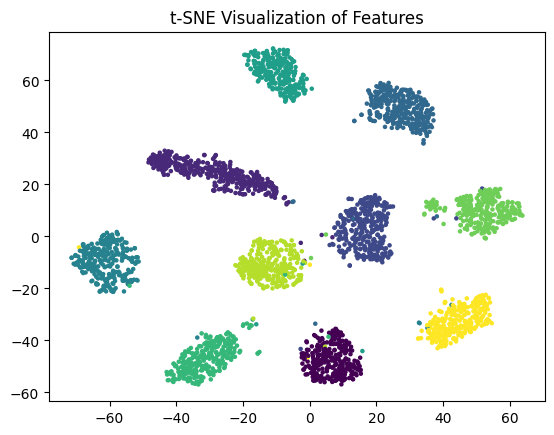

In [9]:
X_embedded, labels_sampled = metrics.tsne_batch(
    loader=BaseLoader(),
    X=X_test,
    y=y_test,
    model=model,
    max_samples=3000,
    n_components=2,
    perplexity=40,
    n_iter=2000
)


plt.scatter(X_embedded[:,0], X_embedded[:,1], c=labels_sampled, s=5)
plt.title("t-SNE Visualization of Features")
plt.show()

# Temp

## BCE/CCE Loss

In [61]:
import torch
import torch.nn as nn
import torch.nn.functional as F


y_true = torch.tensor([1., 0., 1.])
logits = torch.tensor([0.6, -1.1, 2.8], requires_grad=True)
probs = F.sigmoid(logits)  # [0.6457, 0.2497, 0.9427]
probs.retain_grad()

error = nn.BCELoss()
loss = error(probs, y_true)
loss.backward()

print("Loss:", loss)
print("dL/dA:", logits.grad)
print("dA/dI", probs.grad)

Loss: tensor(0.2613, grad_fn=<BinaryCrossEntropyBackward0>)
dL/dA: tensor([-0.1181,  0.0832, -0.0191])
dA/dI tensor([-0.5163,  0.4443, -0.3536])


In [ ]:
# Вр 1
y_true = np.array([1, 0, 1])
logits = np.array([0.6, 0.3, 0.6])

y_true = y_true.flatten()
logits = logits.flatten()

loss = -y_true*np.log(logits) - (1 - y_true)*np.log((1 - logits))
# print(loss)
print(np.mean(loss))

dL = -y_true/logits + (1 - y_true)/(1 - logits)
print(dL)

print("Loss:", loss)
print("dL/dA:", logits.grad)
print("dA/dI", probs.grad)

[-1.66666667  1.42857143 -1.66666667]


In [8]:
# Вр 2
y_true = np.array([1, 0, 1])
logits = np.array([[0.6], [0.3], [0.6]])

y_true = y_true.flatten()
logits = logits.flatten()

# loss = -y_true*np.log(logits) - (1 - y_true)*np.log((1 - logits))
# print(loss)
# print(np.mean(loss))

dL = -y_true/logits + (1 - y_true)/(1 - logits)
print(dL)

[-1.66666667  1.42857143 -1.66666667]


In [18]:
# Вр 3
y_true = np.array([1, 0, 1])
logits = np.array([
    [0.4, 0.6],
    [0.7, 0.3],
    [0.4, 0.6]
])

y_true = y_true.flatten()
n_batch = len(logits)

# loss = -np.log(logits[np.arange(n_batch), y_true])
# print(loss)
# print(np.mean(loss))

dL = logits.copy()
dL[np.arange(n_batch), y_true] -= 1

# from src.tools import utils
# dL = logits - utils.to_one_hot(y_true, 2)

print(dL)

[[ 0.4 -0.4]
 [-0.3  0.3]
 [ 0.4 -0.4]]


In [96]:
import torch
import torch.nn as nn
import torch.nn.functional as F


y_true = torch.tensor([0, 1, 2])
logits = torch.tensor([
    [2.6, 0.1, -1.3],
    [0.4, 2.5, 1.1],
    [1.05, 0.05, -2.9],
], requires_grad=True)
probs = F.log_softmax(logits, dim=-1)
"""
[[-0.0974, -2.5974, -3.9974],
[-2.4141, -0.3141, -1.7141],
[-0.3272, -1.3272, -4.2772]]
"""
probs.retain_grad()

error = nn.NLLLoss()
loss = error(probs, y_true)
loss.backward()

print("Loss:", loss)
print("dL/dA:", logits.grad)
print("dA/dI", probs.grad)

Loss: tensor(1.5629, grad_fn=<NllLossBackward0>)
dL/dA: tensor([[-0.0309,  0.0248,  0.0061],
        [ 0.0298, -0.0899,  0.0600],
        [ 0.2403,  0.0884, -0.3287]])
dA/dI tensor([[-0.3333,  0.0000,  0.0000],
        [ 0.0000, -0.3333,  0.0000],
        [ 0.0000,  0.0000, -0.3333]])


In [104]:
# Вр 4
softmax = SoftmaxActivation(is_log=True, is_before_cce=True)
error = CrossEntropyLoss(is_binary=False, type_logits='log_softmax')

y_true = np.array([0, 1, 2])
logits = np.array([
    [2.6, 0.1, -1.3],
    [0.4, 2.5, 1.1],
    [1.05, 0.05, -2.9],
])
probs = softmax(logits)

# Loss
loss = error(y_true, probs)
# dL
dL = error.backward_pass(probs)
# dA
# dA = softmax.backward_pass(logits)
sm = np.exp(probs)
sum_delta = np.sum(dL, axis=1, keepdims=True)
dA = dL - sum_delta * sm

print("Loss:", loss)
print("dL/dA:", dL)
print("dA/dI", dA)

Loss: 1.5629275719573867
dL/dA: [[-0.0309427   0.02482173  0.00612096]
 [ 0.02981535 -0.0898561   0.06004075]
 [ 0.2403036   0.08840276 -0.32870636]]
dA/dI [[-0.0309427   0.02482173  0.00612096]
 [ 0.02981535 -0.0898561   0.06004075]
 [ 0.2403036   0.08840276 -0.32870636]]


In [129]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# ----- PyTorch -----
y_true = torch.tensor([0, 1, 2])
logits = torch.tensor([
    [2.6, 0.1, -1.3],
    [0.4, 2.5, 1.1],
    [1.05, 0.05, -2.9],
], requires_grad=True)
log_probs = F.log_softmax(logits, dim=-1)
log_probs.retain_grad()

error = nn.NLLLoss()
loss = error(log_probs, y_true)
loss.backward()

print("Loss:", loss)
print("dA/dI", log_probs.grad)
print("dL/dI:", logits.grad)

print()
# ----- Custom -----
y_true = np.array([0, 1, 2])
logits = np.array([
    [2.6, 0.1, -1.3],
    [0.4, 2.5, 1.1],
    [1.05, 0.05, -2.9],
])
shifted = logits - np.max(logits, axis=-1, keepdims=True)
probs = np.exp(shifted) / np.sum(np.exp(shifted), axis=-1, keepdims=True)
log_probs = np.log(probs)

# Loss
n_batch = len(log_probs)
loss = -log_probs[np.arange(n_batch), y_true]
loss = np.mean(loss)
# dL_dA
dL_dA = np.zeros_like(log_probs)
dL_dA[np.arange(n_batch), y_true] = -1
dL_dA = dL_dA/n_batch
# dA
dA = np.zeros((n_batch, 3, 3))  # Тензор 3x3x3
for i in range(n_batch):
    for j in range(3):
        for k in range(3):
            dA[i, j, k] = (1 if j == k else 0) - probs[i, k]

# dL_dI
new_delta = np.zeros_like(logits)
for i in range(n_batch):
    for j in range(3):
        for k in range(3):
            new_delta[i, j] += dL[i, k] * dA[i, k, j]

print("Loss:", loss)
print("dA/dI", dL_dA)
print("dL/dI:", new_delta)

Loss: tensor(1.5629, grad_fn=<NllLossBackward0>)
dA/dI tensor([[-0.3333,  0.0000,  0.0000],
        [ 0.0000, -0.3333,  0.0000],
        [ 0.0000,  0.0000, -0.3333]])
dL/dI: tensor([[-0.0309,  0.0248,  0.0061],
        [ 0.0298, -0.0899,  0.0600],
        [ 0.2403,  0.0884, -0.3287]])

Loss: 1.5629275719573867
dA/dI [[-0.33333333  0.          0.        ]
 [ 0.         -0.33333333  0.        ]
 [ 0.          0.         -0.33333333]]
dL/dI: [[-0.0309427   0.02482173  0.00612096]
 [ 0.02981535 -0.0898561   0.06004075]
 [ 0.2403036   0.08840276 -0.32870636]]


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# ----- PyTorch -----
y_true = torch.tensor([0, 1, 2])
logits = torch.tensor([
    [2.6, 0.1, -1.3],
    [0.4, 2.5, 1.1],
    [1.05, 0.05, -2.9],
], requires_grad=True)

error = nn.CrossEntropyLoss()
loss = error(logits, y_true)
loss.backward()

print("Loss:", loss)
print("dL/dI:", logits.grad)

print()
# ----- Custom -----
softmax = SoftmaxActivation(is_log=False)
error = CrossEntropyLoss(type_logits='softmax')

y_true = np.array([0, 1, 2])
logits = np.array([
    [2.6, 0.1, -1.3],
    [0.4, 2.5, 1.1],
    [1.05, 0.05, -2.9],
])
probs = softmax(logits)

loss = error(y_true, probs)

dL_dA = error.backward_pass(probs)
dL_dI = softmax.backward_pass(dL_dA)

print("Loss:", loss)
print("dL/dI:", dL_dI)

Loss: tensor(1.5629, grad_fn=<NllLossBackward0>)
dL/dI: tensor([[-0.0309,  0.0248,  0.0061],
        [ 0.0298, -0.0899,  0.0600],
        [ 0.2403,  0.0884, -0.3287]])

Loss: 1.5629275719573867
dL/dI: [[-0.0309427   0.02482173  0.00612096]
 [ 0.02981535 -0.0898561   0.06004075]
 [ 0.2403036   0.08840276 -0.32870636]]


## Weights

In [ ]:
class tCNN(nn.Module):
    def __init__(self):
        super(tCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=5)
        self.conv3 = nn.Conv2d(32,64, kernel_size=5)
        self.fc1 = nn.Linear(3*3*64, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        #x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(F.max_pool2d(self.conv3(x),2))
        x = F.dropout(x, p=0.5, training=self.training)
        x = x.view(-1,3*3*64)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

tmodel = tCNN()

test_model = CNN([
    optConvLayer(in_channels=1, out_channels=32, kernel_size=5, stride=1, padding=0, bias=True, padding_mode='constant'),
    ReLUActivation(),

    optConvLayer(in_channels=32, out_channels=32, kernel_size=5, stride=1, padding=0, bias=True, padding_mode='constant'),
    MaxPoolLayer(kernel_size=2),
    ReLUActivation(),
    DropoutLayer(dropout_rate=0.5),

    optConvLayer(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=0, bias=True, padding_mode='constant'),
    MaxPoolLayer(kernel_size=2),
    ReLUActivation(),
    DropoutLayer(dropout_rate=0.5),
    
    FlattenLayer(),

    LinearLayer(in_features=64*3*3, out_features=256, bias=True),
    DropoutLayer(dropout_rate=0.5),
    
    LinearLayer(in_features=256, out_features=10, bias=True),
    SoftmaxActivation(is_log=True)
])

# weights = {}
# for name, param in tmodel.named_parameters():
#     name_layer, name_weight = name.split('.')
#     weights[name_layer] = {name_weight: param.detach().numpy()} if name_weight == 'weight' else weights[name_layer] | {name_weight: param.detach().numpy()}

# for layer, new_weights in zip(model.get_weights_layers(), weights.values()):
#     new_W, new_b = new_weights.values()
#     layer.update_weights(new_W, new_b)

utils.share_weights(tmodel, model)

In [ ]:
test2_pytorch_model

In [25]:
# Инициализируем Loss и оптимизатор
loss = CrossEntropyLoss(type_logits='log_softmax')
data_loader = ShuffleLoader(batch_size=32)
optimizer = AdamOptimizer(
    model_weights_layers=model.get_weights_layers(),
    data_loader=data_loader,
    lr=0.001,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-7
)

In [28]:
def postprocess(y_probs: np.ndarray) -> np.ndarray:
    y_preds = np.argmax(y_probs, axis=-1)
    return y_preds

# Задаём параметры обучения и запускаем его
n_epochs = 10
verbose_n_batch_multiple = 50
model.train_model(
    n_epochs,
    X_train, y_train, X_val, y_val,
    loss, optimizer,
    postprocess=postprocess, count_metric=accuracy_score,
    verbose_n_batch_multiple=verbose_n_batch_multiple, verbose_statistic='EMA'
)

Epoch 1 (0/48510):	Train CrossEntropyLoss = 2.294	Val CrossEntropyLoss = 2.294	accuracy_score = 0.098
Epoch 1 (1600/48510):	Train CrossEntropyLoss = 2.298	Val CrossEntropyLoss = 2.298	accuracy_score = 0.105
Epoch 1 (3200/48510):	Train CrossEntropyLoss = 2.299	Val CrossEntropyLoss = 2.299	accuracy_score = 0.105


KeyboardInterrupt: 

## Conv forward pass

In [54]:
inputs = X_train[:3]

custom_conv = ConvLayer(in_channels=1, out_channels=5, kernel_size=5, stride=1, padding=0, bias=True)
opt_conv = optConvLayer(in_channels=1, out_channels=5, kernel_size=5, stride=1, padding=0, bias=True)
pytorch_conv = nn.Conv2d(in_channels=1, out_channels=5, kernel_size=5, stride=1, padding=0, bias=True)

W, b = custom_conv.get_weights()
with torch.no_grad():
    pytorch_conv.weight.data = torch.from_numpy(W)
    pytorch_conv.bias.data = torch.from_numpy(b)

opt_conv.update_weights(W, b)

In [55]:
custom_outputs = custom_conv(inputs)
opt_outputs = opt_conv(inputs)
pytorch_outputs = pytorch_conv(torch.from_numpy(inputs)).detach().numpy()

In [56]:
custom_outputs.shape

(3, 5, 24, 24)

In [40]:
r = 4
print(np.unique(np.round(pytorch_outputs, r) == np.round(custom_outputs, r), return_counts=True))
print(np.unique(np.round(pytorch_outputs, r) == np.round(opt_outputs, r), return_counts=True))

(array([False,  True]), array([   1, 8639]))
(array([False,  True]), array([   2, 8638]))


In [ ]:
mask = np.round(pytorch_outputs, r) != np.round(custom_outputs, r)
print(np.round(pytorch_outputs, r)[mask])
print()
print(np.round(custom_outputs, r)[mask])

[0.4661]

[0.4662]


## Conv backward pass

In [3]:
custom_conv = ConvLayer(in_channels=1, out_channels=5, kernel_size=5, stride=1, padding=0, bias=True)
opt_conv = optConvLayer(in_channels=1, out_channels=5, kernel_size=5, stride=1, padding=0, bias=True)
pytorch_conv = nn.Conv2d(in_channels=1, out_channels=5, kernel_size=5, stride=1, padding=0, bias=True)

W, b = custom_conv.get_weights()
with torch.no_grad():
    pytorch_conv.weight.data = torch.from_numpy(W)
    pytorch_conv.bias.data = torch.from_numpy(b)

opt_conv.update_weights(W, b)

In [4]:
# Генерим данные
N, C_in, H, W = 3, 1, 12, 12
X = np.random.randn(N, C_in, H, W).astype(np.float32)
delta = np.random.randn(N, 5, 8, 8).astype(np.float32)

X_t = torch.tensor(X, requires_grad=True)
delta_t = torch.tensor(delta)

In [5]:
# Считаем градиенты
custom_output = custom_conv(X)
custom_grad_input = custom_conv.backward_pass(delta)
custom_gradW = custom_conv.gradW
custom_gradb = custom_conv.gradb

opt_output = opt_conv(X)
opt_grad_input = opt_conv.backward_pass(delta)
opt_gradW = opt_conv.gradW
opt_gradb = opt_conv.gradb

pytorch_output = pytorch_conv(X_t)
pytorch_output.backward(delta_t)
pytorch_gradW = pytorch_conv.weight.grad.detach().numpy()
pytorch_gradb = pytorch_conv.bias.grad.detach().numpy()
pytorch_grad_input = X_t.grad.detach().numpy()

In [6]:
print("gradW error:", np.abs(custom_gradW - pytorch_gradW).max())
print("gradb error:", np.abs(custom_gradb - pytorch_gradb).max())
print("grad_input error:", np.abs(custom_grad_input - pytorch_grad_input).max())
print()
print("gradW error:", np.abs(opt_gradW - pytorch_gradW).max())
print("gradb error:", np.abs(opt_gradb - pytorch_gradb).max())
print("grad_input error:", np.abs(opt_grad_input - pytorch_grad_input).max())

gradW error: 1.1444092e-05
gradb error: 7.6293945e-06
grad_input error: 1.1920929e-06

gradW error: 4.7683716e-06
gradb error: 7.6293945e-06
grad_input error: 1.1920929e-06


In [7]:
r = 4
print(np.unique(np.round(pytorch_gradW, r) == np.round(custom_gradW, r), return_counts=True))
print(np.unique(np.round(pytorch_gradW, r) == np.round(opt_gradW, r), return_counts=True))

(array([False,  True]), array([  4, 121]))
(array([ True]), array([125]))


In [8]:
mask = np.round(pytorch_gradW, r) != np.round(custom_gradW, r)
print(np.round(pytorch_gradW, r)[mask])
print(np.round(custom_gradW, r)[mask])
print()
mask = np.round(pytorch_gradW, r) != np.round(opt_gradW, r)
print(np.round(pytorch_gradW, r)[mask])
print(np.round(opt_gradW, r)[mask])

[32.5149 11.9932 17.0718 13.39  ]
[32.5148 11.9931 17.0717 13.3899]

[]
[]


## PyTorch training

In [ ]:
# Temp
def fit(EPOCHS, model, train_loader, optimizer, error):
    model.train()
    for epoch in range(EPOCHS):
        correct = 0
        for batch_idx, (X_batch, y_batch) in enumerate(train_loader):
            var_X_batch = Variable(X_batch).float()
            var_y_batch = Variable(y_batch)
            optimizer.zero_grad()
            output = model(var_X_batch)
            loss = error(output, var_y_batch)
            loss.backward()
            optimizer.step()

            # Total correct predictions
            predicted = torch.max(output.data, 1)[1] 
            correct += (predicted == var_y_batch).sum()
            #print(correct)
            if batch_idx % 50 == 0:
                print('Epoch : {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}\t Accuracy:{:.3f}%'.format(
                    epoch,
                    batch_idx*len(X_batch),
                    len(train_loader.dataset),
                    100.*batch_idx / len(train_loader),
                    loss,
                    float(correct*100) / float(BATCH_SIZE*(batch_idx+1))
                ))


class tCNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=5)
        self.conv3 = nn.Conv2d(32,64, kernel_size=5)
        self.fc1 = nn.Linear(3*3*64, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        #x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(F.max_pool2d(self.conv3(x),2))
        x = F.dropout(x, p=0.5, training=self.training)
        x = x.view(-1,3*3*64)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)


BATCH_SIZE = 32
torch_X_train = torch.from_numpy(X_train)
torch_y_train = torch.from_numpy(y_train) # data type is long
# create feature and targets tensor for test set.
torch_X_test = torch.from_numpy(X_test)
torch_y_test = torch.from_numpy(y_test) # data type is long
# Pytorch train and test sets
train = torch.utils.data.TensorDataset(torch_X_train,torch_y_train)
test = torch.utils.data.TensorDataset(torch_X_test,torch_y_test)
# data loader
train_loader = torch.utils.data.DataLoader(train, batch_size = BATCH_SIZE, shuffle = False)
test_loader = torch.utils.data.DataLoader(test, batch_size = BATCH_SIZE, shuffle = False)

model = tCNN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.999))
error = nn.CrossEntropyLoss()
EPOCHS = 5
fit(EPOCHS, model, train_loader, optimizer, error)

torch.Size([48510])
torch.Size([21000])
Epoch : 0 [0/48510 (0%)]	Loss: 2.311680	 Accuracy:9.375%
Epoch : 0 [1600/48510 (3%)]	Loss: 1.394505	 Accuracy:29.779%
Epoch : 0 [3200/48510 (7%)]	Loss: 0.631341	 Accuracy:50.557%
Epoch : 0 [4800/48510 (10%)]	Loss: 0.686956	 Accuracy:60.720%
Epoch : 0 [6400/48510 (13%)]	Loss: 0.447487	 Accuracy:66.775%
Epoch : 0 [8000/48510 (16%)]	Loss: 0.245800	 Accuracy:71.464%
Epoch : 0 [9600/48510 (20%)]	Loss: 0.313382	 Accuracy:74.595%
Epoch : 0 [11200/48510 (23%)]	Loss: 0.161696	 Accuracy:76.861%
Epoch : 0 [12800/48510 (26%)]	Loss: 0.663628	 Accuracy:78.725%
Epoch : 0 [14400/48510 (30%)]	Loss: 0.586854	 Accuracy:79.982%
Epoch : 0 [16000/48510 (33%)]	Loss: 0.268836	 Accuracy:81.294%
Epoch : 0 [17600/48510 (36%)]	Loss: 0.238864	 Accuracy:82.345%
Epoch : 0 [19200/48510 (40%)]	Loss: 0.154235	 Accuracy:83.293%
Epoch : 0 [20800/48510 (43%)]	Loss: 0.266228	 Accuracy:84.025%
Epoch : 0 [22400/48510 (46%)]	Loss: 0.176049	 Accuracy:84.714%
Epoch : 0 [24000/48510 (49%)]